# 설명 가능한 인공지능

## 1. 설명 가능한 인공지능의 필요성과 등장 배경

인간은 결정을 내릴 때 그 이유를 타인에게 설명하는 능력을 갖추고 있음. 은행은 대출 거절의 이유를 고객에게 설명하고, 의사는 진단이나 처방의 근거를 환자에게 설명하며, 판사는 판결문을 통해 법적 판단의 이유를 전달함. 이러한 설명은 **상대방의 납득**과 **사회적 신뢰**를 유도하는 핵심 요소임.

인공지능도 인간 전문가를 대체하려면 이와 같은 **설명 능력**을 갖추어야 함. 그러나 현재의 딥러닝 기반 인공지능은 수백만 개의 파라미터와 복잡한 연산을 통해 결론을 도출하기 때문에 내부 동작 원리를 설명하기 어려움. 이로 인해 "블랙박스" 모델이라 불리며 신뢰 부족 문제를 야기함.

이에 따라 미국 국방부 산하 DARPA는 2017년부터 **설명 가능한 인공지능(XAI, eXplainable AI)** 프로젝트를 시작함. 해당 프로젝트의 목적은 성능을 유지하면서도 내부 작동이 투명하게 드러나는 **"유리박스" 모델**을 개발하는 것임.

또한, 유럽연합은 2016년 제정된 GDPR(General Data Protection Regulation)에서 알고리즘 기반 의사결정에 대해 **설명을 요구할 권리(right to explanation)**를 명문화함. 이는 인공지능 시스템이 사회적 규범과 법적 책임을 함께 져야 한다는 의미임.

---

## 2. 설명 가능한 고전적 모델: 결정트리(Decision Tree)

### 2.1 유리박스 모델로서의 결정트리

결정트리는 사람이 전체 의사결정 과정을 **직관적으로 이해**할 수 있는 대표적 기계학습 모델임. 각 노드는 **질문 형태의 조건**을 포함하고, 샘플은 조건을 따라 트리를 이동하면서 최종 결정에 도달함. 이 구조는 **루트 노드 → 내부 노드 → 리프 노드**로 구성되는 이진 트리임.

예를 들어, 유방암 데이터셋을 활용해 트리를 학습한 경우, 루트 노드에서 "worst radius ≤ 16.795"라는 조건을 제시하고, 해당 조건의 참/거짓 여부에 따라 샘플이 다음 노드로 이동함. 이 과정을 반복한 후 리프 노드에 도달하면, 해당 노드에 할당된 클래스(예: malignant)를 최종 예측 결과로 판단함.

### 2.2 트리 학습의 수학적 기반: 지니 계수(Gini Index)

트리를 학습할 때는 각 노드에서 데이터를 어떻게 분할할지를 결정해야 하며, 이 때 **지니 계수**를 사용함. 지니 계수는 해당 노드에 존재하는 샘플들의 **불순도(heterogeneity)**를 수치화한 값이며, 값이 작을수록 동질성이 높음을 의미함. 즉, 지니 계수가 작아지도록 데이터를 분할하는 조건을 반복적으로 찾아가는 방식이 트리 학습의 핵심임.

### 2.3 결정트리의 장점과 한계

- **장점**: 의사결정 경로가 명확하여 **설명 가능성**이 매우 높음. 모든 노드의 조건을 사람이 읽고 해석할 수 있음.
- **한계**: 실제 데이터는 비선형적이고 고차원적인 경우가 많으며, 결정트리는 이러한 복잡한 패턴을 **단순한 선형 분할**로만 처리하기 때문에 **성능이 낮아질 가능성**이 높음. 특히, 영상이나 음성처럼 특성이 직관적이지 않은 데이터에서는 설명력도 떨어짐.

---

## 3. 설명 수준의 단계와 딥러닝의 설명력 부족

인공지능의 설명 능력은 다음의 3단계로 나뉘며, 현재 딥러닝 모델은 대부분 1단계 혹은 2단계에 머물러 있음.

| 수준 | 설명 내용 | 실현 가능 여부 |
| --- | --- | --- |
| 1단계 | 예측 결과만 제공 | 현실에서 대부분 이 수준에 해당 |
| 2단계 | 입력 중 어떤 부분을 참고했는지를 시각적으로 표현 | Grad-CAM 등으로 일부 실현 가능 |
| 3단계 | 사람처럼 자연어로 예측 근거를 설명 | 현재 기술로는 미흡함, 연구 진행 중 |

예: 인공지능이 "이 이미지는 91.5% 확률로 '붉은 날개 검은새'입니다."라고만 출력한다면 이는 1단계 수준임. 반면, "이 새의 날개에 있는 붉은 점 부위를 보고 판단했습니다."라고 말한다면 이는 3단계에 가까움.

---

## 4. CNN 기반 딥러닝 모델에서 설명 기능 추가하기

### 4.1 CAM (Class Activation Map)

CAM은 CNN의 마지막 컨볼루션 층에서 출력된 **특징맵**을 기반으로, 모델이 어떤 부위를 보고 판단했는지를 **열지도 형태로 시각화**하는 기법임.

단, CAM은 **전역 평균 풀링(Global Average Pooling)** 구조에만 적용 가능하다는 한계가 있음. 대부분의 실제 모델은 완전 연결층을 사용하기 때문에 적용 제약이 큼.

### 4.2 Grad-CAM (Gradient-weighted CAM)

Grad-CAM은 CAM의 확장 기법으로, CNN의 구조에 **제약 없이 적용 가능**하다는 장점이 있음. 핵심 원리는 다음과 같음.

- 마지막 컨볼루션 층의 출력인 feature map에 대해, 해당 부류(class c)의 확률을 이 map에 대해 **미분**함
- 미분 결과로 얻은 gradient를 통해 각 특징맵이 결과에 기여한 **가중치**를 산출함
- 각 feature map에 가중치를 곱해 합산하여 열지도를 생성함

이 과정을 통해, 모델이 **결정을 내리는 데 중점적으로 본 이미지 영역**을 시각적으로 확인할 수 있음.

---

## Grad-CAM 실습 (ResNet50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


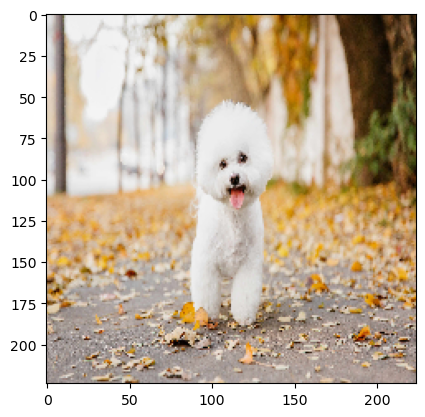

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50, resnet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from PIL import Image

# [1] 이미지 로딩 및 전처리
img = image.load_img("image.png", target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = resnet50.preprocess_input(x)

# [2] 사전 학습된 모델 로드
model = ResNet50(weights='imagenet')
preds = model.predict(x)
pred_class = np.argmax(preds[0])

# [3] 마지막 컨볼루션 층을 출력으로 하는 모델 구성
last_conv_layer = model.get_layer('conv5_block3_out')
grad_model = Model(inputs=model.input, outputs=[last_conv_layer.output, model.output])

# [4] Gradient 계산
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, pred_class]

# gradient: (1, H, W, C)
grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)) 

# [5] heatmap 계산
conv_outputs = conv_outputs[0].numpy()    
pooled_grads = pooled_grads.numpy()        

for i in range(pooled_grads.shape[0]):
    conv_outputs[:, :, i] *= pooled_grads[i]  

heatmap = np.mean(conv_outputs, axis=-1)     
heatmap = np.maximum(heatmap, 0)            
heatmap /= np.max(heatmap)                   

# [6] 시각화
plt.imshow(img)


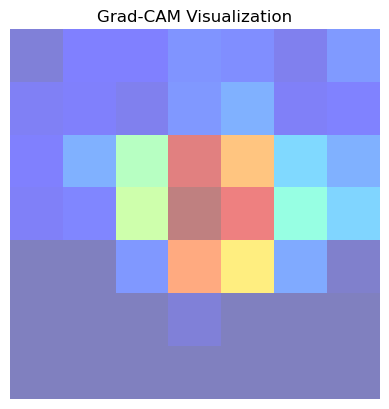

In [11]:
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("Grad-CAM Visualization")
plt.show()